# PHASE 0 — Data Organisation & Pairing
## Multimodal Maritime Object Detection Using SAR and Optical Satellite Imagery
---
**Team 22UG0005 | Panel No. 5 | Guide: Mr. Nagesh Koundinya Subbanna**

### What this notebook does:
1. Reads ALL train_OPTICAL + test_OPTICAL images
2. Pairs them with already-generated train_SAR + test_SAR images
3. Renames ALL pairs sequentially (0001_opt.png / 0001_sar.png)
4. Updates the CSV with new sequential names
5. Saves demo samples for panel
6. Produces summary report

---
### Folder structure (your machine):
```
AIRBUS-SHIP-DETECTION/
    train_OPTICAL/     <- raw train optical images  (INPUT)
    train_SAR/         <- raw train SAR images      (INPUT)
    test_OPTICAL/      <- raw test optical images   (INPUT)
    test_SAR/          <- raw test SAR images       (INPUT)
    train_ship_segmentations_v2.csv                 (INPUT)
    code/
        dataset/
            train_OPTICAL/   <- renamed train optical  (OUTPUT)
            train_SAR/       <- renamed train SAR       (OUTPUT)
            test_OPTICAL/    <- renamed test optical    (OUTPUT)
            test_SAR/        <- renamed test SAR        (OUTPUT)
            train_labels_clean.csv                      (OUTPUT)
            samples/         <- panel demo images       (OUTPUT)
```

## Cell 1: Install & Import Libraries

In [1]:
import subprocess, sys
required = ['opencv-python', 'numpy', 'pandas', 'matplotlib', 'Pillow', 'tqdm']
for pkg in required:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All libraries installed successfully.')

All libraries installed successfully.


In [4]:
import os, re, sys
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Fix Windows Unicode printing
import io

## Cell 2: Configuration — SET YOUR PATHS HERE

In [5]:
# =====================================================================
#   EDIT ONLY THIS CELL — set the root folder of your dataset
# =====================================================================

# Root folder — the AIRBUS-SHIP-DETECTION folder on your machine
ROOT = r'C:\Users\VaishnaviM\Downloads\airbus-ship-detection'

# ── INPUTS (already exist on your disk) ──────────────────────────────
RAW_TRAIN_OPTICAL = os.path.join(ROOT, 'train_OPTICAL')
RAW_TRAIN_SAR     = os.path.join(ROOT, 'train_SAR')
RAW_TEST_OPTICAL  = os.path.join(ROOT, 'test_OPTICAL')
RAW_TEST_SAR      = os.path.join(ROOT, 'test_SAR')
RAW_CSV_PATH      = os.path.join(ROOT, 'train_ship_segmentations_v2.csv')

# ── OUTPUTS (will be created inside code/dataset/) ────────────────────
CODE_DIR          = os.path.join(ROOT, 'code')
DATASET_DIR       = os.path.join(CODE_DIR, 'dataset')

OUT_TRAIN_OPTICAL = os.path.join(DATASET_DIR, 'train_OPTICAL')
OUT_TRAIN_SAR     = os.path.join(DATASET_DIR, 'train_SAR')
OUT_TEST_OPTICAL  = os.path.join(DATASET_DIR, 'test_OPTICAL')
OUT_TEST_SAR      = os.path.join(DATASET_DIR, 'test_SAR')
OUT_SAMPLES       = os.path.join(DATASET_DIR, 'samples')
OUT_TRAIN_CSV     = os.path.join(DATASET_DIR, 'train_labels_clean.csv')
SUMMARY_FILE      = os.path.join(CODE_DIR,    'phase0_summary.txt')

# ── SETTINGS ──────────────────────────────────────────────────────────
MAX_TRAIN_IMAGES  = None   # None = ALL train images (~192,556)
MAX_TEST_IMAGES   = None   # None = ALL test images  (~15,000)
NUM_SAMPLES       = 10     # pairs to save as panel demo images
TARGET_SIZE       = (768, 768)  # output image size

# ── Create output directories ──────────────────────────────────────────
for d in [OUT_TRAIN_OPTICAL, OUT_TRAIN_SAR,
          OUT_TEST_OPTICAL,  OUT_TEST_SAR, OUT_SAMPLES]:
    os.makedirs(d, exist_ok=True)

print('Configuration loaded.')
print(f'  ROOT              : {ROOT}')
print(f'  RAW train optical : {RAW_TRAIN_OPTICAL}')
print(f'  RAW train SAR     : {RAW_TRAIN_SAR}')
print(f'  RAW test optical  : {RAW_TEST_OPTICAL}')
print(f'  RAW test SAR      : {RAW_TEST_SAR}')
print(f'  Output dataset    : {DATASET_DIR}')
print(f'  Max train images  : {MAX_TRAIN_IMAGES if MAX_TRAIN_IMAGES else "ALL"}')
print(f'  Max test images   : {MAX_TEST_IMAGES  if MAX_TEST_IMAGES  else "ALL"}')

Configuration loaded.
  ROOT              : C:\Users\VaishnaviM\Downloads\airbus-ship-detection
  RAW train optical : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\train_OPTICAL
  RAW train SAR     : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\train_SAR
  RAW test optical  : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\test_OPTICAL
  RAW test SAR      : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\test_SAR
  Output dataset    : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\code\dataset
  Max train images  : ALL
  Max test images   : ALL



Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



## Cell 3: Verify All Input Folders Exist

In [6]:
print('Checking input folders...')
print('-' * 55)

checks = {
    'train_OPTICAL' : RAW_TRAIN_OPTICAL,
    'train_SAR'     : RAW_TRAIN_SAR,
    'test_OPTICAL'  : RAW_TEST_OPTICAL,
    'test_SAR'      : RAW_TEST_SAR,
    'CSV file'      : RAW_CSV_PATH,
}

all_ok = True
for name, path in checks.items():
    exists = os.path.exists(path)
    status = 'OK' if exists else 'MISSING'
    print(f'  [{status:^7}]  {name:15} -> {path}')
    if not exists:
        all_ok = False

if not all_ok:
    raise FileNotFoundError('One or more input paths are missing. Fix the paths in Cell 2.')

print()

# Count files in each folder
def count_images(folder):
    return sorted([f for f in os.listdir(folder)
                   if f.lower().endswith(('.jpg','.jpeg','.png'))])

train_opt_files = count_images(RAW_TRAIN_OPTICAL)
train_sar_files = count_images(RAW_TRAIN_SAR)
test_opt_files  = count_images(RAW_TEST_OPTICAL)
test_sar_files  = count_images(RAW_TEST_SAR)
raw_csv         = pd.read_csv(RAW_CSV_PATH)

print(f'  train_OPTICAL : {len(train_opt_files):>8,} images')
print(f'  train_SAR     : {len(train_sar_files):>8,} images')
print(f'  test_OPTICAL  : {len(test_opt_files):>8,} images')
print(f'  test_SAR      : {len(test_sar_files):>8,} images')
print(f'  CSV rows      : {len(raw_csv):>8,}')
print()

# Apply limits
train_opt_files = train_opt_files[:MAX_TRAIN_IMAGES] if MAX_TRAIN_IMAGES else train_opt_files
test_opt_files  = test_opt_files[:MAX_TEST_IMAGES]   if MAX_TEST_IMAGES  else test_opt_files

print(f'  Will process TRAIN : {len(train_opt_files):,} images')
print(f'  Will process TEST  : {len(test_opt_files):,} images')
print()
print('All input folders verified OK.')

Checking input folders...
-------------------------------------------------------
  [  OK   ]  train_OPTICAL   -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\train_OPTICAL
  [  OK   ]  train_SAR       -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\train_SAR
  [  OK   ]  test_OPTICAL    -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\test_OPTICAL
  [  OK   ]  test_SAR        -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\test_SAR
  [  OK   ]  CSV file        -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\train_ship_segmentations_v2.csv

  train_OPTICAL :  192,960 images
  train_SAR     :  192,959 images
  test_OPTICAL  :   15,606 images
  test_SAR      :   15,606 images
  CSV rows      :  231,723

  Will process TRAIN : 192,960 images
  Will process TEST  : 15,606 images

All input folders verified OK.


## Cell 4: Clean the Ground Truth CSV

In [7]:
print('Cleaning ground truth CSV...')
print('-' * 55)

print(f'  Total rows in raw CSV     : {len(raw_csv):,}')
print(f'  Unique image IDs in CSV   : {raw_csv["ImageId"].nunique():,}')
print(f'  Rows with ships           : {raw_csv["EncodedPixels"].notna().sum():,}')
print(f'  Rows with no ships (NaN)  : {raw_csv["EncodedPixels"].isna().sum():,}')
print()

# Build lookup: original_filename -> list of RLE encoded pixel strings
# This will be used to remap the CSV during the pairing loop
csv_lookup = raw_csv.groupby('ImageId')['EncodedPixels'].apply(list).to_dict()

print(f'  CSV lookup built for {len(csv_lookup):,} unique image IDs.')
print()
print('Sample of original CSV ImageIds (first 5):')
for k in list(csv_lookup.keys())[:5]:
    print(f'    {k}  ->  {len(csv_lookup[k])} ship annotation(s)')
print()
print('CSV ready for remapping.')

Cleaning ground truth CSV...
-------------------------------------------------------
  Total rows in raw CSV     : 231,723
  Unique image IDs in CSV   : 192,556
  Rows with ships           : 81,723
  Rows with no ships (NaN)  : 150,000

  CSV lookup built for 192,556 unique image IDs.

Sample of original CSV ImageIds (first 5):
    00003e153.jpg  ->  1 ship annotation(s)
    0001124c7.jpg  ->  1 ship annotation(s)
    000155de5.jpg  ->  1 ship annotation(s)
    000194a2d.jpg  ->  5 ship annotation(s)
    0001b1832.jpg  ->  1 ship annotation(s)

CSV ready for remapping.


## Cell 5: Define SAR Simulation Pipeline (only used if SAR is missing)

In [8]:
# NOTE: Since your train_SAR/ and test_SAR/ folders already exist,
# the main loop will directly COPY and RENAME those files.
# This simulation function is only called as a FALLBACK
# if a SAR file is missing for a given optical image.

def simulate_sar(optical_bgr, seed=42):
    """6-stage optical to SAR simulation. Used only as fallback."""
    rng     = np.random.default_rng(seed)
    gray    = cv2.cvtColor(optical_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    sar     = np.power(gray, 0.6)                                      # Stage 1: radiometric
    speckle = np.clip(rng.rayleigh(0.12, sar.shape).astype(np.float32), 0.5, 1.5)
    sar     = sar * speckle                                            # Stage 2: speckle
    kernel  = np.array([[0,-0.5,0],[-0.5,3,-0.5],[0,-0.5,0]], np.float32)
    sar     = np.clip(cv2.filter2D(np.clip(sar*255,0,255).astype(np.uint8),-1,kernel)
                      .astype(np.float32)/255.0, 0, 1)                 # Stage 3: edge sharpen
    sar     = cv2.GaussianBlur(sar, (3,3), 0.8)                        # Stage 4: texture suppress
    sar[sar < 0.25] *= 0.5                                             # Stage 5: tonal shift
    sar[sar > 0.70]  = np.clip(sar[sar > 0.70] * 1.3, 0, 1)
    sar     = np.clip(0.05 + np.clip(sar,0,1) * 0.80, 0, 1)           # Stage 6: contrast compress
    return np.clip(sar * 255, 0, 255).astype(np.uint8)

print('SAR simulation fallback function defined.')
print('Main loop will use existing SAR files from train_SAR/ and test_SAR/')

SAR simulation fallback function defined.
Main loop will use existing SAR files from train_SAR/ and test_SAR/


## Cell 6: Process ALL TRAIN Images — Rename, Pair, Save, Remap CSV

In [9]:
print('PROCESSING TRAIN IMAGES')
print(f'  Input optical : {RAW_TRAIN_OPTICAL}')
print(f'  Input SAR     : {RAW_TRAIN_SAR}')
print(f'  Output optical: {OUT_TRAIN_OPTICAL}')
print(f'  Output SAR    : {OUT_TRAIN_SAR}')
print(f'  Total to process : {len(train_opt_files):,} train images')
print()

train_records  = []   # rows for the new cleaned CSV
train_failed   = []
train_sar_generated = 0   # count of SAR files generated (vs copied)
train_sar_copied    = 0

# Build a lookup: stem (no extension) -> full SAR filename
# This handles cases where optical is .jpg but SAR is .png
sar_stem_lookup = {}
for f in os.listdir(RAW_TRAIN_SAR):
    stem = os.path.splitext(f)[0]   # e.g. '00021ddc3'
    sar_stem_lookup[stem] = f

for idx, opt_fname in enumerate(tqdm(train_opt_files,
                                      desc='Train pairs', unit='img')):
    seq_id   = f'{idx + 1:05d}'                  # 00001, 00002, ...
    new_opt  = f'{seq_id}_opt.png'
    new_sar  = f'{seq_id}_sar.png'
    out_opt  = os.path.join(OUT_TRAIN_OPTICAL, new_opt)
    out_sar  = os.path.join(OUT_TRAIN_SAR,     new_sar)
    src_opt  = os.path.join(RAW_TRAIN_OPTICAL,  opt_fname)

    # Find matching SAR file (same stem, any extension)
    opt_stem = os.path.splitext(opt_fname)[0]
    sar_fname = sar_stem_lookup.get(opt_stem, None)

    try:
        # ── Read and save optical ────────────────────────────────────
        img_bgr = cv2.imread(src_opt, cv2.IMREAD_COLOR)
        if img_bgr is None:
            raise ValueError(f'Cannot read optical: {src_opt}')
        img_bgr = cv2.resize(img_bgr, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)
        cv2.imwrite(out_opt, img_bgr)

        # ── Copy/rename existing SAR or generate fallback ────────────
        if sar_fname is not None:
            src_sar = os.path.join(RAW_TRAIN_SAR, sar_fname)
            sar_img = cv2.imread(src_sar, cv2.IMREAD_GRAYSCALE)
            if sar_img is not None:
                sar_img = cv2.resize(sar_img, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)
                cv2.imwrite(out_sar, sar_img)
                train_sar_copied += 1
            else:
                raise ValueError(f'Cannot read SAR: {src_sar}')
        else:
            # SAR file doesn't exist — generate from optical
            sar_gray = simulate_sar(img_bgr, seed=idx)
            cv2.imwrite(out_sar, sar_gray)
            train_sar_generated += 1

        # ── Remap CSV entry: old filename -> new sequential name ─────
        # Try both with and without extension variants
        rle_list = (csv_lookup.get(opt_fname) or
                    csv_lookup.get(opt_stem + '.jpg') or
                    csv_lookup.get(opt_stem + '.png') or
                    [float('nan')])

        for rle in rle_list:
            train_records.append({
                'ImageId'       : new_opt,
                'EncodedPixels' : rle,
                'OriginalId'    : opt_fname,
                'SeqIndex'      : idx + 1,
                'Split'         : 'train'
            })

    except Exception as e:
        train_failed.append((opt_fname, str(e)))

print()
print('TRAIN processing done!')
print(f'  Successfully processed : {len(train_opt_files) - len(train_failed):,}')
print(f'  SAR copied (existing)  : {train_sar_copied:,}')
print(f'  SAR generated (fallback): {train_sar_generated:,}')
print(f'  Failed                 : {len(train_failed)}')
if train_failed:
    print('  First 5 failures:')
    for fn, err in train_failed[:5]:
        print(f'    {fn}: {err}')

PROCESSING TRAIN IMAGES
  Input optical : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\train_OPTICAL
  Input SAR     : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\train_SAR
  Output optical: C:\Users\VaishnaviM\Downloads\airbus-ship-detection\code\dataset\train_OPTICAL
  Output SAR    : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\code\dataset\train_SAR
  Total to process : 192,960 train images



Train pairs: 100%|██████████| 192960/192960 [8:49:45<00:00,  6.07img/s]   


TRAIN processing done!
  Successfully processed : 192,960
  SAR copied (existing)  : 192,556
  SAR generated (fallback): 404
  Failed                 : 0


## Cell 7: Process ALL TEST Images — Rename and Pair

In [10]:
print('PROCESSING TEST IMAGES')
print(f'  Input optical : {RAW_TEST_OPTICAL}')
print(f'  Input SAR     : {RAW_TEST_SAR}')
print(f'  Output optical: {OUT_TEST_OPTICAL}')
print(f'  Output SAR    : {OUT_TEST_SAR}')
print(f'  Total to process : {len(test_opt_files):,} test images')
print()

test_failed        = []
test_sar_copied    = 0
test_sar_generated = 0

# Build SAR stem lookup for test set
test_sar_stem_lookup = {}
for f in os.listdir(RAW_TEST_SAR):
    stem = os.path.splitext(f)[0]
    test_sar_stem_lookup[stem] = f

for idx, opt_fname in enumerate(tqdm(test_opt_files,
                                      desc='Test pairs', unit='img')):
    seq_id  = f'{idx + 1:05d}'
    new_opt = f'{seq_id}_opt.png'
    new_sar = f'{seq_id}_sar.png'
    out_opt = os.path.join(OUT_TEST_OPTICAL, new_opt)
    out_sar = os.path.join(OUT_TEST_SAR,     new_sar)
    src_opt = os.path.join(RAW_TEST_OPTICAL, opt_fname)

    opt_stem  = os.path.splitext(opt_fname)[0]
    sar_fname = test_sar_stem_lookup.get(opt_stem, None)

    try:
        # Read and save optical
        img_bgr = cv2.imread(src_opt, cv2.IMREAD_COLOR)
        if img_bgr is None:
            raise ValueError(f'Cannot read: {src_opt}')
        img_bgr = cv2.resize(img_bgr, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)
        cv2.imwrite(out_opt, img_bgr)

        # Copy/rename existing SAR or generate fallback
        if sar_fname is not None:
            src_sar = os.path.join(RAW_TEST_SAR, sar_fname)
            sar_img = cv2.imread(src_sar, cv2.IMREAD_GRAYSCALE)
            if sar_img is not None:
                sar_img = cv2.resize(sar_img, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)
                cv2.imwrite(out_sar, sar_img)
                test_sar_copied += 1
            else:
                raise ValueError(f'Cannot read SAR: {src_sar}')
        else:
            sar_gray = simulate_sar(img_bgr, seed=idx)
            cv2.imwrite(out_sar, sar_gray)
            test_sar_generated += 1

    except Exception as e:
        test_failed.append((opt_fname, str(e)))

print()
print('TEST processing done!')
print(f'  Successfully processed  : {len(test_opt_files) - len(test_failed):,}')
print(f'  SAR copied (existing)   : {test_sar_copied:,}')
print(f'  SAR generated (fallback): {test_sar_generated:,}')
print(f'  Failed                  : {len(test_failed)}')
if test_failed:
    print('  First 5 failures:')
    for fn, err in test_failed[:5]:
        print(f'    {fn}: {err}')

PROCESSING TEST IMAGES
  Input optical : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\test_OPTICAL
  Input SAR     : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\test_SAR
  Output optical: C:\Users\VaishnaviM\Downloads\airbus-ship-detection\code\dataset\test_OPTICAL
  Output SAR    : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\code\dataset\test_SAR
  Total to process : 15,606 test images



Test pairs: 100%|██████████| 15606/15606 [40:56<00:00,  6.35img/s] 


TEST processing done!
  Successfully processed  : 15,606
  SAR copied (existing)   : 15,606
  SAR generated (fallback): 0
  Failed                  : 0


## Cell 8: Save Cleaned CSV with New Sequential Names

In [11]:
print('Saving cleaned CSV...')

clean_df = pd.DataFrame(train_records)

ship_images = clean_df[clean_df['EncodedPixels'].notna()]['ImageId'].nunique()
bg_images   = clean_df[clean_df['EncodedPixels'].isna()]['ImageId'].nunique()

clean_df.to_csv(OUT_TRAIN_CSV, index=False, encoding='utf-8')

print(f'  Saved to       : {OUT_TRAIN_CSV}')
print(f'  Total rows     : {len(clean_df):,}')
print(f'  Unique images  : {clean_df["ImageId"].nunique():,}')
print(f'  With ships     : {ship_images:,}')
print(f'  Background     : {bg_images:,}')
print()
print('Preview of new CSV (first 10 rows):')
print(clean_df[['ImageId','EncodedPixels','OriginalId']].head(10).to_string(index=False))

Saving cleaned CSV...
  Saved to       : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\code\dataset\train_labels_clean.csv
  Total rows     : 232,127
  Unique images  : 192,960
  With ships     : 42,556
  Background     : 150,404

Preview of new CSV (first 10 rows):
      ImageId                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

## Cell 9: Verify All Pairs Are Correctly Renamed

In [12]:
print('VERIFICATION — Checking renamed pairs')

def verify_pairs(opt_dir, sar_dir, label):
    opt_set = set(f for f in os.listdir(opt_dir) if f.endswith('_opt.png'))
    sar_set = set(f for f in os.listdir(sar_dir) if f.endswith('_sar.png'))
    matched, missing_sar, missing_opt = [], [], []
    for o in opt_set:
        s = o.replace('_opt.png', '_sar.png')
        if s in sar_set: matched.append(o.replace('_opt.png',''))
        else: missing_sar.append(o)
    for s in sar_set:
        o = s.replace('_sar.png', '_opt.png')
        if o not in opt_set: missing_opt.append(s)
    print(f'  [{label}]')
    print(f'    Matched pairs   : {len(matched):,}')
    print(f'    Missing SAR     : {len(missing_sar)}')
    print(f'    Missing optical : {len(missing_opt)}')
    if matched:
        print(f'    First 3 pairs   : ', end='')
        print(', '.join(sorted(matched)[:3]))
    print()
    return len(matched)

train_matched = verify_pairs(OUT_TRAIN_OPTICAL, OUT_TRAIN_SAR, 'TRAIN')
test_matched  = verify_pairs(OUT_TEST_OPTICAL,  OUT_TEST_SAR,  'TEST')

print(f'  TOTAL matched pairs (train + test) : {train_matched + test_matched:,}')
print()
print('All pairs verified!')

VERIFICATION — Checking renamed pairs
  [TRAIN]
    Matched pairs   : 193,460
    Missing SAR     : 0
    Missing optical : 0
    First 3 pairs   : 00001, 00002, 00003

  [TEST]
    Matched pairs   : 15,606
    Missing SAR     : 0
    Missing optical : 0
    First 3 pairs   : 00001, 00002, 00003

  TOTAL matched pairs (train + test) : 209,066

All pairs verified!


## Cell 10: Save Side-by-Side Panel Demo Images

Saving 10 side-by-side optical/SAR demo pairs...


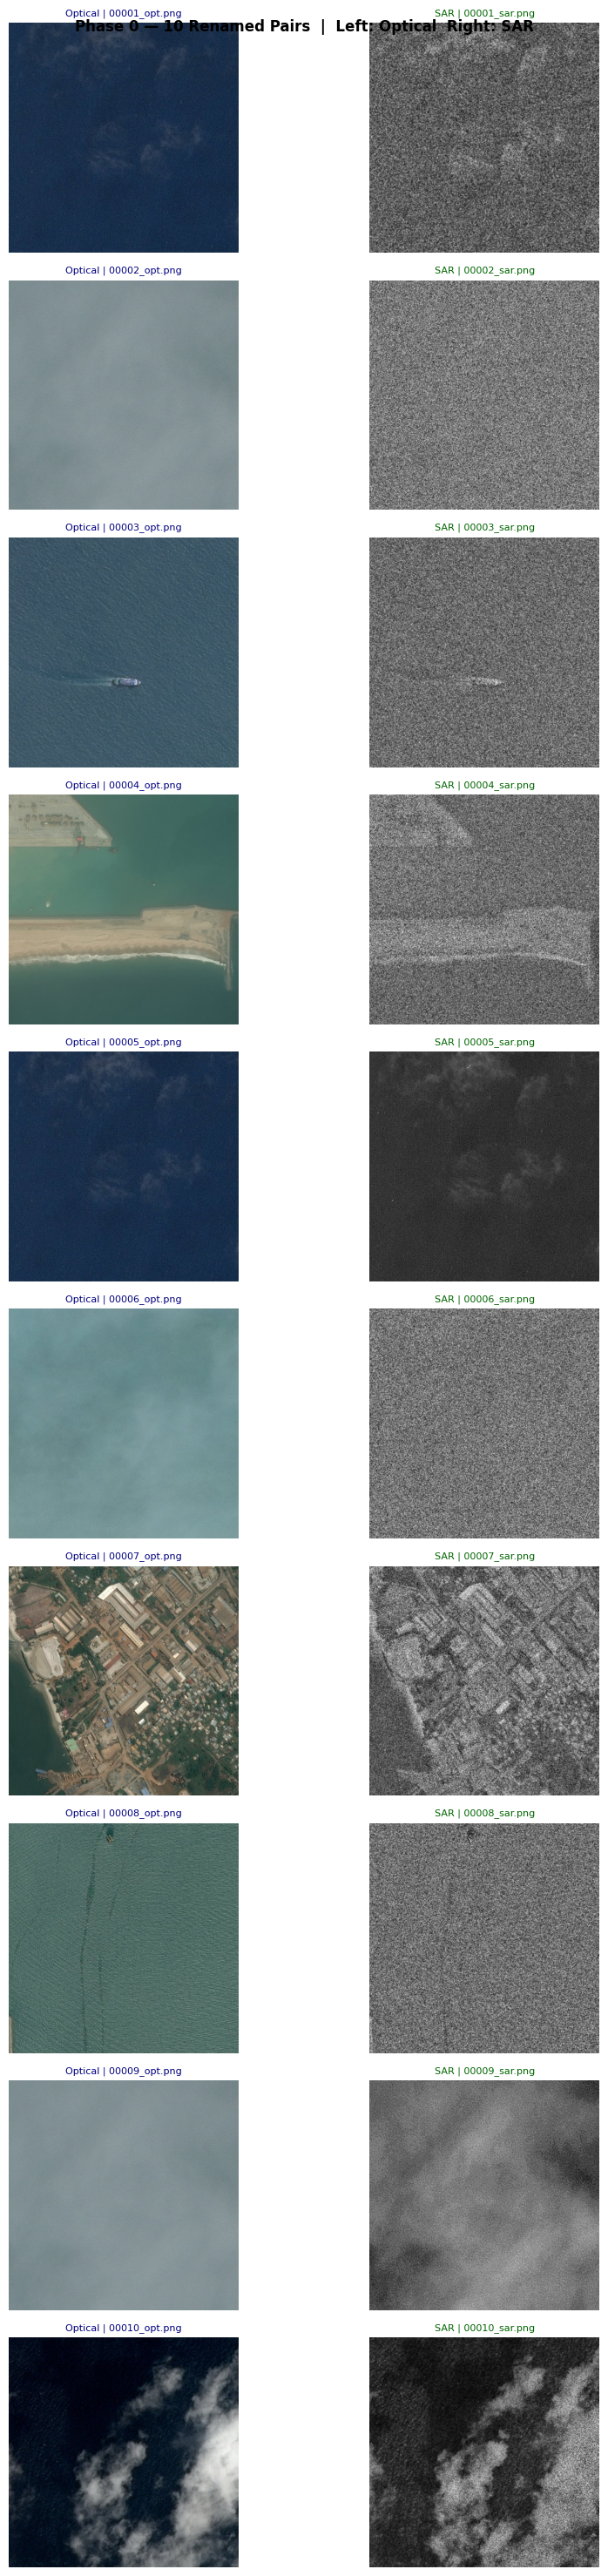

  Saved 10 pairs -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\code\dataset\samples\paired_samples_panel_demo.png


In [13]:
print(f'Saving {NUM_SAMPLES} side-by-side optical/SAR demo pairs...')

sample_opts = sorted([f for f in os.listdir(OUT_TRAIN_OPTICAL)
                       if f.endswith('_opt.png')])[:NUM_SAMPLES]

fig, axes = plt.subplots(NUM_SAMPLES, 2, figsize=(10, NUM_SAMPLES * 3))
fig.suptitle(f'Phase 0 — {NUM_SAMPLES} Renamed Pairs  |  Left: Optical  Right: SAR',
             fontsize=12, fontweight='bold')

saved = 0
for i, opt_name in enumerate(sample_opts):
    sar_name = opt_name.replace('_opt.png', '_sar.png')
    op = cv2.imread(os.path.join(OUT_TRAIN_OPTICAL, opt_name))
    sr = cv2.imread(os.path.join(OUT_TRAIN_SAR,     sar_name), cv2.IMREAD_GRAYSCALE)
    if op is None or sr is None:
        continue
    axes[i][0].imshow(cv2.cvtColor(op, cv2.COLOR_BGR2RGB))
    axes[i][0].set_title(f'Optical | {opt_name}', fontsize=8, color='navy')
    axes[i][0].axis('off')
    axes[i][1].imshow(sr, cmap='gray')
    axes[i][1].set_title(f'SAR | {sar_name}', fontsize=8, color='darkgreen')
    axes[i][1].axis('off')
    saved += 1

plt.tight_layout()
demo_path = os.path.join(OUT_SAMPLES, 'paired_samples_panel_demo.png')
plt.savefig(demo_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'  Saved {saved} pairs -> {demo_path}')

## Cell 11: Statistics Dashboard

Computing statistics...


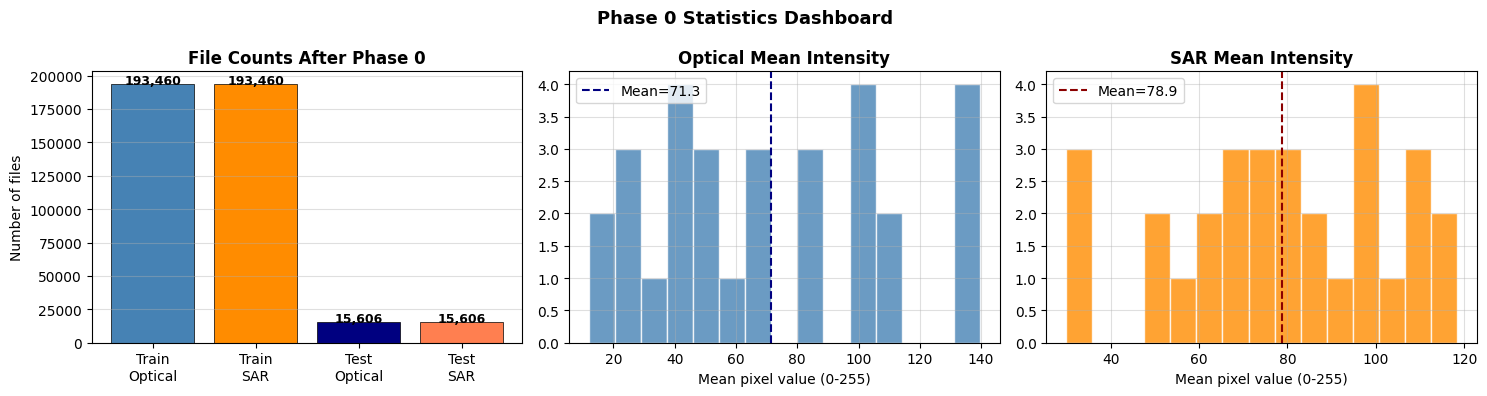

  Statistics saved -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\code\dataset\samples\phase0_statistics.png


In [14]:
print('Computing statistics...')

STAT_N = 30
opt_means, sar_means = [], []
sample_files = sorted(os.listdir(OUT_TRAIN_OPTICAL))[:STAT_N]

for f in sample_files:
    s = f.replace('_opt.png','_sar.png')
    o = cv2.imread(os.path.join(OUT_TRAIN_OPTICAL, f), cv2.IMREAD_GRAYSCALE)
    r = cv2.imread(os.path.join(OUT_TRAIN_SAR,     s), cv2.IMREAD_GRAYSCALE)
    if o is not None: opt_means.append(o.mean())
    if r is not None: sar_means.append(r.mean())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Phase 0 Statistics Dashboard', fontsize=13, fontweight='bold')

# File counts
ax = axes[0]
cats   = ['Train\nOptical','Train\nSAR','Test\nOptical','Test\nSAR']
counts = [len(os.listdir(OUT_TRAIN_OPTICAL)),
          len(os.listdir(OUT_TRAIN_SAR)),
          len(os.listdir(OUT_TEST_OPTICAL)),
          len(os.listdir(OUT_TEST_SAR))]
bars = ax.bar(cats, counts, color=['steelblue','darkorange','navy','coral'],
               edgecolor='black', linewidth=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+10,
            f'{int(b.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('File Counts After Phase 0', fontweight='bold')
ax.set_ylabel('Number of files')
ax.grid(axis='y', alpha=0.4)

# Optical histogram
ax = axes[1]
ax.hist(opt_means, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(opt_means), color='navy', linestyle='--',
           label=f'Mean={np.mean(opt_means):.1f}')
ax.set_title('Optical Mean Intensity', fontweight='bold')
ax.set_xlabel('Mean pixel value (0-255)')
ax.legend(); ax.grid(alpha=0.4)

# SAR histogram
ax = axes[2]
ax.hist(sar_means, bins=15, color='darkorange', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(sar_means), color='darkred', linestyle='--',
           label=f'Mean={np.mean(sar_means):.1f}')
ax.set_title('SAR Mean Intensity', fontweight='bold')
ax.set_xlabel('Mean pixel value (0-255)')
ax.legend(); ax.grid(alpha=0.4)

plt.tight_layout()
stats_path = os.path.join(OUT_SAMPLES, 'phase0_statistics.png')
plt.savefig(stats_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'  Statistics saved -> {stats_path}')

## Cell 12: Final Summary Report

In [15]:
# FIX: open with encoding='utf-8' to avoid Windows cp1252 UnicodeEncodeError

summary_lines = [
    '=' * 65,
    'PHASE 0 - DATA ORGANISATION & PAIRING - SUMMARY REPORT',
    f'Run at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
    '=' * 65,
    '',
    'PROJECT: Multimodal Maritime Object Detection (SAR + Optical)',
    'Team: 22UG0005 | Panel: 5 | Guide: Mr. Nagesh Koundinya Subbanna',
    '',
    '-- INPUTS --',
    f'Train optical folder  : {RAW_TRAIN_OPTICAL}',
    f'Train SAR folder      : {RAW_TRAIN_SAR}',
    f'Test optical folder   : {RAW_TEST_OPTICAL}',
    f'Test SAR folder       : {RAW_TEST_SAR}',
    f'CSV file              : {RAW_CSV_PATH}',
    '',
    '-- PROCESSING --',
    f'Train images processed: {len(train_opt_files):,}',
    f'Test  images processed: {len(test_opt_files):,}',
    f'Train SAR copied      : {train_sar_copied:,}',
    f'Train SAR generated   : {train_sar_generated:,}',
    f'Test  SAR copied      : {test_sar_copied:,}',
    f'Test  SAR generated   : {test_sar_generated:,}',
    f'Train failures        : {len(train_failed)}',
    f'Test  failures        : {len(test_failed)}',
    '',
    '-- OUTPUTS --',
    f'Train optical out     : {OUT_TRAIN_OPTICAL}',
    f'Train SAR out         : {OUT_TRAIN_SAR}',
    f'Test  optical out     : {OUT_TEST_OPTICAL}',
    f'Test  SAR out         : {OUT_TEST_SAR}',
    f'Cleaned CSV           : {OUT_TRAIN_CSV}',
    f'CSV rows              : {len(clean_df):,}',
    f'Images with ships     : {ship_images:,}',
    f'Background images     : {bg_images:,}',
    '',
    '-- NAMING CONVENTION --',
    'Train: 00001_opt.png <-> 00001_sar.png',
    'Test : 00001_opt.png <-> 00001_sar.png',
    'CSV ImageId updated to new sequential names',
    '',
    '-- NEXT STEP --',
    'Run PHASE1_Preprocessing.ipynb',
    '=' * 65,
]

#  FIX: encoding='utf-8' prevents Windows UnicodeEncodeError
with open(SUMMARY_FILE, 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary_lines))

print('\n'.join(summary_lines))
print()
print(f'Summary saved -> {SUMMARY_FILE}')
print()
print('PHASE 0 COMPLETE!')
print(f'  Train pairs ready : {len(os.listdir(OUT_TRAIN_OPTICAL)):,}')
print(f'  Test  pairs ready : {len(os.listdir(OUT_TEST_OPTICAL)):,}')
print()
print('Ready for Phase 1: Preprocessing')

PHASE 0 - DATA ORGANISATION & PAIRING - SUMMARY REPORT
Run at: 2026-04-20 21:09:30

PROJECT: Multimodal Maritime Object Detection (SAR + Optical)
Team: 22UG0005 | Panel: 5 | Guide: Mr. Nagesh Koundinya Subbanna

-- INPUTS --
Train optical folder  : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\train_OPTICAL
Train SAR folder      : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\train_SAR
Test optical folder   : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\test_OPTICAL
Test SAR folder       : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\test_SAR
CSV file              : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\train_ship_segmentations_v2.csv

-- PROCESSING --
Train images processed: 192,960
Test  images processed: 15,606
Train SAR copied      : 192,556
Train SAR generated   : 404
Test  SAR copied      : 15,606
Test  SAR generated   : 0
Train failures        : 0
Test  failures        : 0

-- OUTPUTS --
Train optical out     : C:\Users\VaishnaviM\Download